TensorFlow: 2.20.0
Train samples: 25000
Test samples: 25000
Validation size: 5000
Test size: 20000


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 200, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 60s 19ms/step - accuracy: 0.6780 - loss: 0.5908 - val_accuracy: 0.7904 - val_loss: 0.4791
Epoch 2/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 84s 20ms/step - accuracy: 0.7388 - loss: 0.5249 - val_accuracy: 0.6634 - val_loss: 0.6095
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 79s 19ms/step - accuracy: 0.7646 - loss: 0.4866 - val_accuracy: 0.7260 - val_loss: 0.5614
Epoch 4/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 82s 19ms/step - accuracy: 0.8392 - loss: 0.3700 - val_accuracy: 0.7812 - val_loss: 0.5049
Epoch 5/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 83s 19ms/step - accuracy: 0.8471 - loss: 0.3545 - val_accuracy: 0.7798 - val_loss: 0.4918


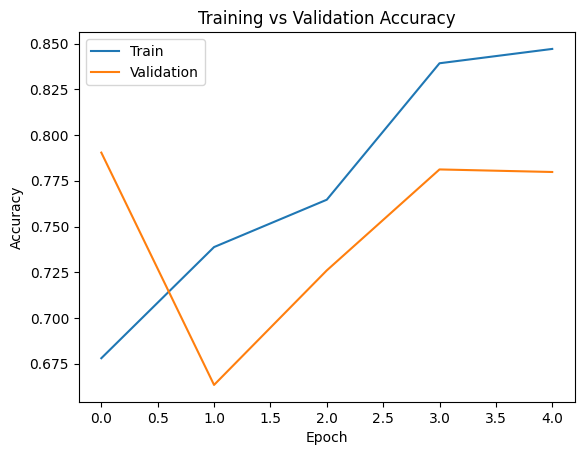

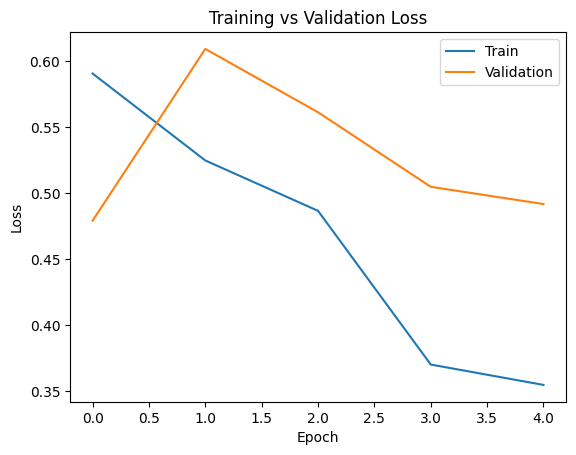

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7854 - loss: 0.4766
Final Test Accuracy: 78.54499816894531 %
Final Test Loss: 0.47664979100227356


In [3]:
# ==========================================
# RNN Sentiment Classification
# TensorFlow / Keras
# IMDB Built-in Dataset
# ==========================================

import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

print("TensorFlow:", tf.__version__)

# ==========================================
# 1 Load Dataset
# ==========================================

vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Train samples:", len(x_train))
print("Test samples:", len(x_test))

# ==========================================
# 2 Take Validation from Test Data
# ==========================================

x_valid = x_test[:5000]
y_valid = y_test[:5000]

x_test = x_test[5000:]
y_test = y_test[5000:]

print("Validation size:", len(x_valid))
print("Test size:", len(x_test))

# ==========================================
# 3 Padding
# ==========================================

max_length = 200

x_train = pad_sequences(x_train, maxlen=max_length)
x_valid = pad_sequences(x_valid, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# ==========================================
# 4 Build RNN Model
# ==========================================

model = Sequential([
    
    Input(shape=(max_length,)),
    
    Embedding(vocab_size, 32),
    
    SimpleRNN(32),
    
    Dense(1, activation="sigmoid")

])

model.summary()

# ==========================================
# 5 Compile Model
# ==========================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ==========================================
# 6 Train Model
# ==========================================

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=8,
    validation_data=(x_valid, y_valid)
)

# ==========================================
# 7 Plot Accuracy
# ==========================================

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

# ==========================================
# 8 Plot Loss
# ==========================================

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

# ==========================================
# 9 Final Evaluation
# ==========================================

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Final Test Accuracy:", test_acc * 100, "%")
print("Final Test Loss:", test_loss)

C:\Users\23adsb61\.conda\envs\tensorflow61\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TensorFlow: 2.10.0
Train samples: 25000
Test samples: 25000
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 32)           320000    
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                2080      
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 322,113
Trainable params: 322,113
Non-trainable params: 0
_________________________________________________________________
Epoch 1/80
391/391 [==============================] - 15s 37ms/step - loss: 0.5906 - accuracy: 0.6608 - val_loss: 0.4251 - val_accuracy: 0.8110
Epoch 2/80
391/391 [==============================] - 16s 42ms/step - loss: 0.3306 - accuracy: 0.8632 - val_lo

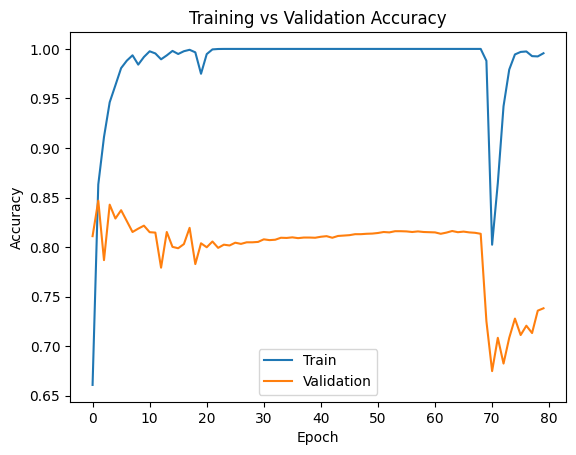

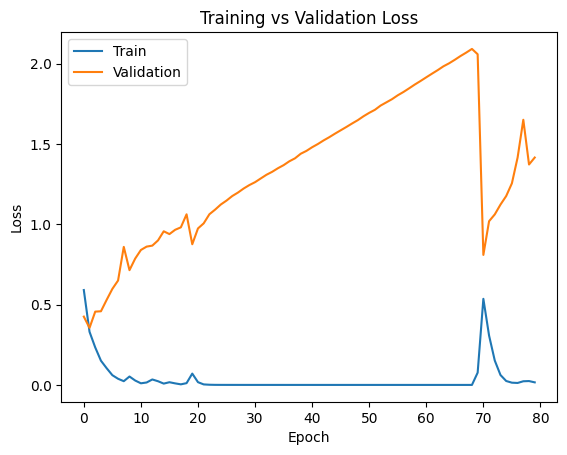

625/625 [==============================] - 4s 7ms/step - loss: 1.3540 - accuracy: 0.7453
Final Test Accuracy: 74.52999949455261 %
Final Test Loss: 1.353995442390442
625/625 [==============================] - 4s 7ms/step


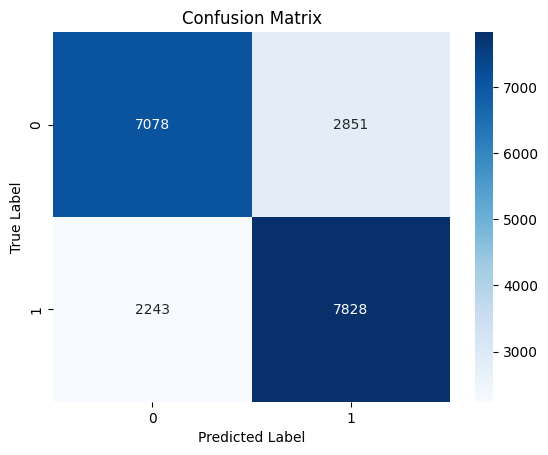


Classification Report

              precision    recall  f1-score   support

           0       0.76      0.71      0.74      9929
           1       0.73      0.78      0.75     10071

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.74     20000
weighted avg       0.75      0.75      0.75     20000

F1 Score: 0.7545060240963856


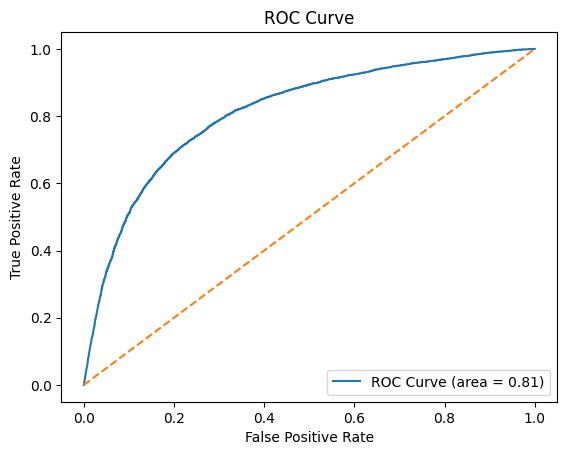

In [1]:
# ==========================================
# RNN Sentiment Classification
# TensorFlow / Keras
# IMDB Dataset
# With Full Evaluation Metrics
# ==========================================

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score

print("TensorFlow:", tf.__version__)

# ==========================================
# 1 Load Dataset
# ==========================================

vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Train samples:", len(x_train))
print("Test samples:", len(x_test))

# ==========================================
# 2 Validation Split
# ==========================================

x_valid = x_test[:5000]
y_valid = y_test[:5000]

x_test = x_test[5000:]
y_test = y_test[5000:]

# ==========================================
# 3 Padding
# ==========================================

max_length = 200

x_train = pad_sequences(x_train, maxlen=max_length)
x_valid = pad_sequences(x_valid, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# ==========================================
# 4 Build RNN Model
# ==========================================

model = Sequential([
    
    Input(shape=(max_length,)),
    
    Embedding(vocab_size, 32),
    
    SimpleRNN(32),
    
    Dense(1, activation="sigmoid")

])

model.summary()

# ==========================================
# 5 Compile Model
# ==========================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ==========================================
# 6 Train Model
# ==========================================

history = model.fit(
    x_train,
    y_train,
    epochs=80,
    batch_size=64,
    validation_data=(x_valid, y_valid)
)

# ==========================================
# 7 Accuracy Plot
# ==========================================

plt.figure()

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

# ==========================================
# 8 Loss Plot
# ==========================================

plt.figure()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

# ==========================================
# 9 Final Evaluation
# ==========================================

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Final Test Accuracy:", test_acc * 100, "%")
print("Final Test Loss:", test_loss)

# ==========================================
# 10 Predictions
# ==========================================

y_pred_prob = model.predict(x_test)

y_pred = (y_pred_prob > 0.5).astype(int)

# ==========================================
# 11 Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure()

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ==========================================
# 12 Classification Report
# ==========================================

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

# ==========================================
# 13 F1 Score
# ==========================================

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

# ==========================================
# 14 ROC Curve
# ==========================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="ROC Curve (area = %0.2f)" % roc_auc)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()